In [7]:
# =========================================
# 1. Import Libraries
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

ModuleNotFoundError: No module named 'pandas'

In [8]:
# =========================================
# 2. Load Dataset
# =========================================
df = pd.read_csv("/kaggle/input/datasets/oktayrdeki/ddos-traffic-dataset/DDoS_dataset.csv")
print("Dataset Shape:", df.shape)

NameError: name 'pd' is not defined

In [3]:
# =========================================
# 3. Remove Data Leakage Feature
# =========================================
if (df["Source IP"] == df["target"]).all():
    print("Dropping Source IP due to data leakage")
    df.drop("Source IP", axis=1, inplace=True)

Dropping Source IP due to data leakage


In [4]:
# =========================================
# 4. Encode Categorical Features
# =========================================
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["Highest Layer", "Transport Layer", "Dest IP"]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Optional: Show encoding mappings (for research paper)
for col in categorical_cols:
    mapping = dict(zip(label_encoders[col].classes_,
                       label_encoders[col].transform(label_encoders[col].classes_)))
    print(f"\nEncoding for {col}:")
    print(mapping)

print("\nEncoding completed successfully.")


Encoding for Highest Layer:
{'ARP': np.int64(0), 'BOOTP': np.int64(1), 'BROWSER': np.int64(2), 'DATA': np.int64(3), 'DHCPV6': np.int64(4), 'LLMNR': np.int64(5), 'NBNS': np.int64(6), 'QUIC': np.int64(7), 'SSDP': np.int64(8), 'TCP': np.int64(9)}

Encoding for Transport Layer:
{'TCP': np.int64(0), 'UDP': np.int64(1)}

Encoding for Dest IP:
{'169.254.198.77': np.int64(0), '169.254.218.126': np.int64(1), '169.254.255.255': np.int64(2), '172.16.255.255': np.int64(3), '172.16.7.100': np.int64(4), '192.168.1.1': np.int64(5), '192.168.1.10': np.int64(6), '192.168.1.11': np.int64(7), '192.168.1.12': np.int64(8), '192.168.1.2': np.int64(9), '192.168.1.255': np.int64(10), '192.168.1.3': np.int64(11), '224.0.0.252': np.int64(12), '239.255.255.250': np.int64(13), '255.255.255.255': np.int64(14), 'ff02::1:2': np.int64(15), 'ff02::1:3': np.int64(16)}

Encoding completed successfully.


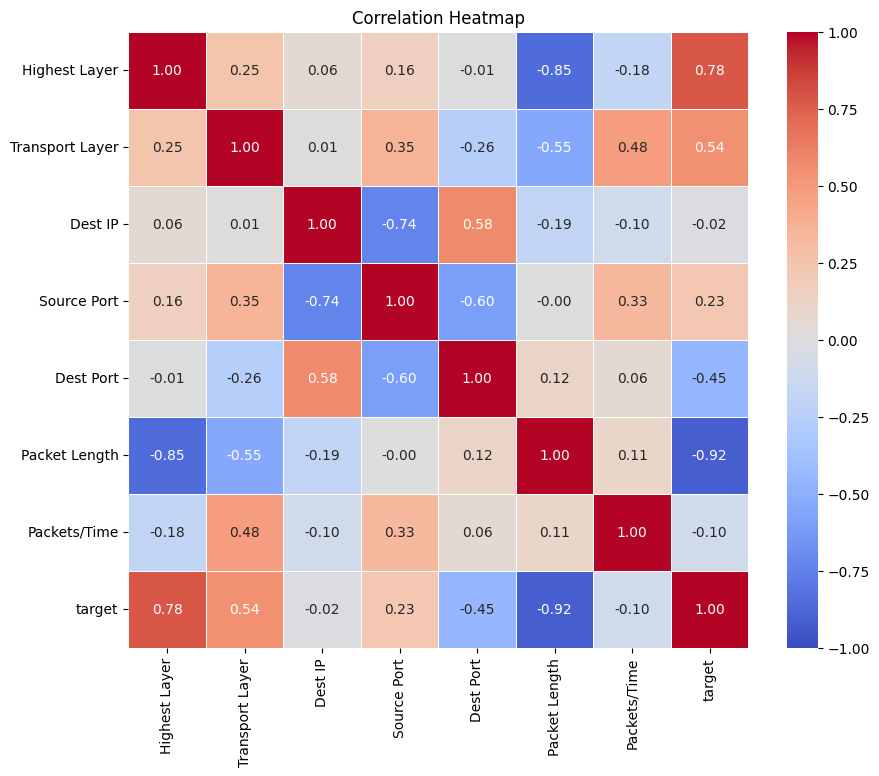

In [5]:
# =========================================
# 5. Correlation Heatmap (Reference Style)
# =========================================
plt.figure(figsize=(10,8))
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title("Correlation Heatmap")
plt.show()

In [6]:
# =========================================
# 6. Correlation Table (Feature vs Target)
# =========================================
corr_target = df.corr(numeric_only=True)["target"].drop("target").sort_values(ascending=False)

corr_table = corr_target.reset_index()
corr_table.columns = ["Feature", "Correlation_with_Target"]

print("\nCorrelation Table (Feature vs Target)")
print(corr_table)


Correlation Table (Feature vs Target)
           Feature  Correlation_with_Target
0    Highest Layer                 0.782798
1  Transport Layer                 0.543415
2      Source Port                 0.227624
3          Dest IP                -0.023216
4     Packets/Time                -0.100678
5        Dest Port                -0.449707
6    Packet Length                -0.917677


/tmp/ipykernel_17/2929493903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


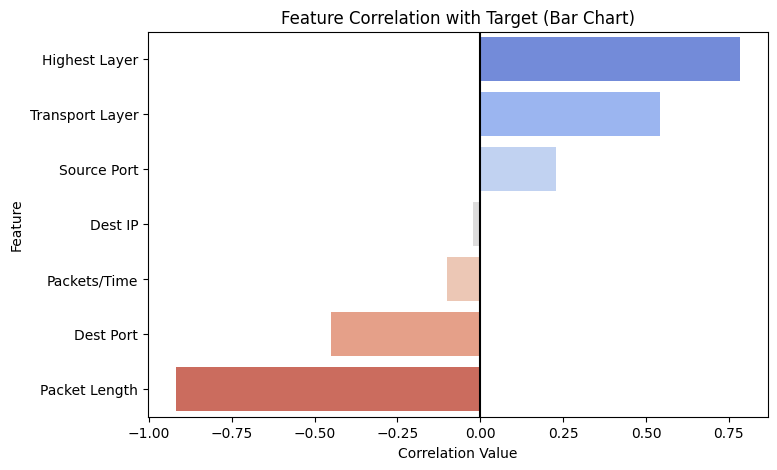

In [7]:
# =========================================
# 7. Correlation Bar Chart
# =========================================
plt.figure(figsize=(8,5))
sns.barplot(
    x="Correlation_with_Target",
    y="Feature",
    data=corr_table,
    palette="coolwarm"
)

plt.title("Feature Correlation with Target (Bar Chart)")
plt.xlabel("Correlation Value")
plt.ylabel("Feature")
plt.axvline(0, color='black')
plt.show()

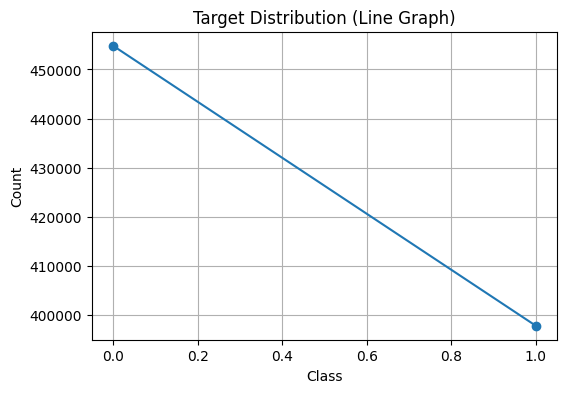

In [8]:
# =========================================
# 8. Target Distribution Line Graph
# =========================================
target_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.plot(target_counts.index, target_counts.values, marker='o')
plt.title("Target Distribution (Line Graph)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(True)
plt.show()

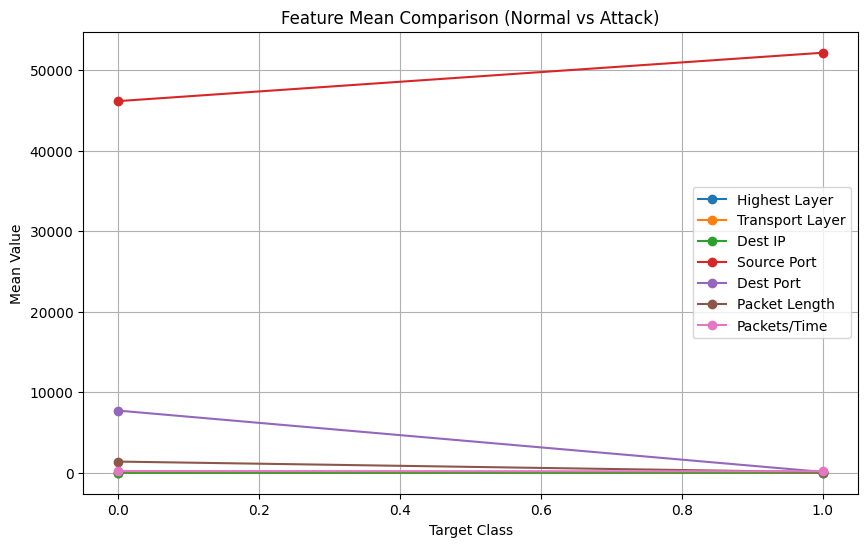

In [9]:
# =========================================
# 9. Feature Mean vs Target Line Graph
# =========================================
feature_means = df.groupby("target").mean(numeric_only=True)

plt.figure(figsize=(10,6))
for column in feature_means.columns:
    if column != "target":
        plt.plot(feature_means.index, feature_means[column], marker='o', label=column)

plt.title("Feature Mean Comparison (Normal vs Attack)")
plt.xlabel("Target Class")
plt.ylabel("Mean Value")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# =========================================
# 10. Split Features & Target
# =========================================
X = df.drop("target", axis=1)
y = df["target"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Show split sizes
print("\nTrain Shape:", X_train.shape, y_train.shape)
print("Test Shape:", X_test.shape, y_test.shape)

# Check class balance after split
print("\nTrain Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest Target Distribution:")
print(y_test.value_counts(normalize=True))

Feature Shape: (852585, 7)
Target Shape: (852585,)

Train Shape: (682068, 7) (682068,)
Test Shape: (170517, 7) (170517,)

Train Target Distribution:
target
0    0.533494
1    0.466506
Name: proportion, dtype: float64

Test Target Distribution:
target
0    0.533495
1    0.466505
Name: proportion, dtype: float64


In [11]:
# =========================================
# 11. Scaling for Logistic Regression
# =========================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before Scaling (First Row):")
print(X_train.iloc[0])

print("\nAfter Scaling (First Row):")
print(X_train_scaled[0])

Before Scaling (First Row):
Highest Layer          3.0
Transport Layer        0.0
Dest IP                5.0
Source Port        49158.0
Dest Port           5201.0
Packet Length       1514.0
Packets/Time         286.2
Name: 424102, dtype: float64

After Scaling (First Row):
[-0.86497736 -0.6143858  -0.21710199  0.01351981  0.12086104  1.04110747
  0.65182364]



Logistic Regression Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     90970
           1       0.99      1.00      0.99     79547

    accuracy                           0.99    170517
   macro avg       0.99      0.99      0.99    170517
weighted avg       0.99      0.99      0.99    170517

Accuracy: 0.993431739943818


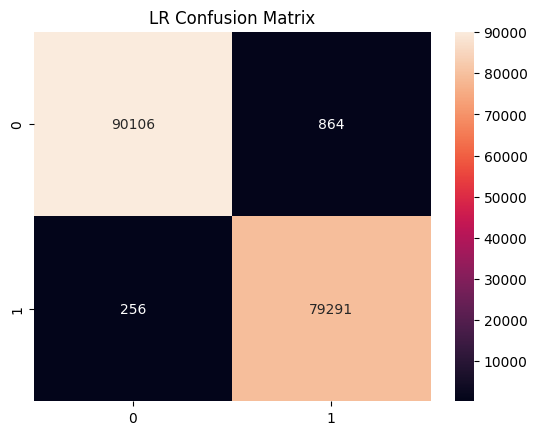

In [12]:
# =========================================
# 12. Logistic Regression
# =========================================
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("\nLogistic Regression Report")
print(classification_report(y_test, lr_pred))
print("Accuracy:", accuracy_score(y_test, lr_pred))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt="d")
plt.title("LR Confusion Matrix")
plt.show()


Random Forest Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90970
           1       1.00      1.00      1.00     79547

    accuracy                           1.00    170517
   macro avg       1.00      1.00      1.00    170517
weighted avg       1.00      1.00      1.00    170517

Accuracy: 0.9999472193388342


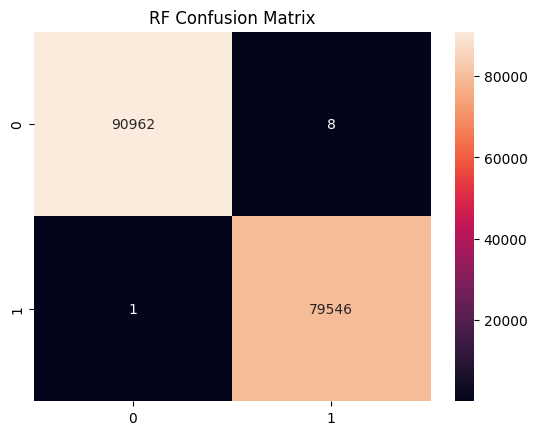

In [13]:
# =========================================
# 13. Random Forest
# =========================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Report")
print(classification_report(y_test, rf_pred))
print("Accuracy:", accuracy_score(y_test, rf_pred))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d")
plt.title("RF Confusion Matrix")
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:18:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90970
           1       1.00      1.00      1.00     79547

    accuracy                           1.00    170517
   macro avg       1.00      1.00      1.00    170517
weighted avg       1.00      1.00      1.00    170517

Accuracy: 0.9999530838567415


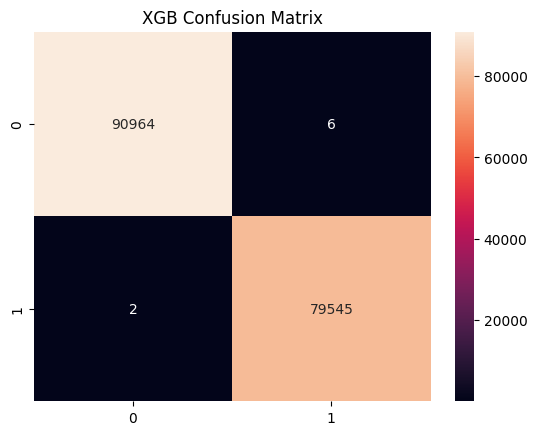

In [14]:
# =========================================
# 14. XGBoost
# =========================================
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("\nXGBoost Report")
print(classification_report(y_test, xgb_pred))
print("Accuracy:", accuracy_score(y_test, xgb_pred))

sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt="d")
plt.title("XGB Confusion Matrix")
plt.show()

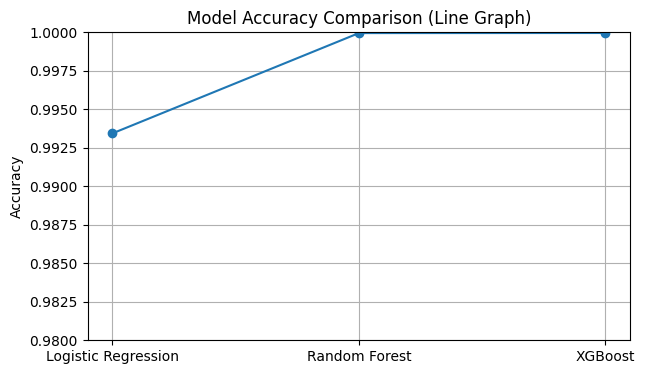

In [15]:
# =========================================
# 15. Accuracy Comparison Line Graph
# =========================================
models = ["Logistic Regression", "Random Forest", "XGBoost"]
accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred)
]

plt.figure(figsize=(7,4))
plt.plot(models, accuracies, marker='o')
plt.title("Model Accuracy Comparison (Line Graph)")
plt.ylabel("Accuracy")
plt.ylim(0.98, 1.0)
plt.grid(True)
plt.show()

In [16]:
# =========================================
# 16. Accuracy Table
# =========================================
accuracy_table = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

print("\nModel Accuracy Table")
print(accuracy_table)


Model Accuracy Table
                 Model  Accuracy
0  Logistic Regression  0.993432
1        Random Forest  0.999947
2              XGBoost  0.999953
